(introduction-rapids-singlecell)=
# GPU-accelerated analysis
```{dropdown} <i class="fas fa-brain"></i>&nbsp;&nbsp;&nbsp;Key takeaways

:::{card}
:link: introduction-rapids-singlecell-key-takeaway-1
:link-type: ref
rapids-singlecell mirrors the scanpy API on the GPU, so most preprocessing and clustering pipelines can be ported by swapping `sc` for `rsc` and moving the AnnData with `rsc.get.anndata_to_GPU`.
:::

:::{card}
:link: introduction-rapids-singlecell-key-takeaway-2
:link-type: ref
Pick exactly one allocator strategy: a pool allocator if the data fits in VRAM, or managed (unified) memory if it does not. Mixing both fragments memory and erodes the speedup.
:::

:::{card}
:link: introduction-rapids-singlecell-key-takeaway-3
:link-type: ref
Move data back to host memory with `rsc.get.anndata_to_CPU` once a step no longer needs the GPU, free intermediate CuPy arrays, and call `cp.get_default_memory_pool().free_all_blocks()` to release VRAM you are no longer using.
:::

:::{card}
:link: introduction-rapids-singlecell-key-takeaway-4
:link-type: ref
For datasets that exceed a single GPU's memory, combine `dask-cuda` with the `read_elem_lazy` AnnData reader to stream chunks through the GPU; expect occasional synchronization points (QC, HVG selection, scaling, PCA) that force evaluation.
:::

```
``````{dropdown} <i class="fa-solid fa-gear"></i>   Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} rapids_singlecell.yml
:language: yaml
```
````

`````
``````
````{dropdown} <i class="fa-solid fa-database"></i>   Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


## Motivation

Most chapters in this book run on CPU and on datasets of tens to hundreds of thousands of cells.
Modern atlases now reach the millions, and the same scanpy-style pipeline that finished in minutes on a laptop can take hours on a workstation and fall over on memory before it finishes.

[rapids-singlecell](https://rapids-singlecell.readthedocs.io/) (RSC) is a scverse core package that ports the scanpy API to the GPU on top of [RAPIDS](https://rapids.ai/), CuPy, and cuML {cite}`rsc:Dicks2026,rsc:Nolet2024`.
It also provides GPU implementations of selected squidpy {cite}`rsc:Palla2022`, decoupler {cite}`rsc:badia2022decoupler`, and pertpy {cite}`rsc:Heumos2025pertpy` routines.
End-to-end speedups of 10–20× over CPU scanpy are typical for the standard preprocessing and clustering pipeline, with individual steps such as UMAP, t-SNE, and Leiden running 50–200× faster.

## When does a GPU pay off?

GPUs help when the work is regular and large enough to amortize the host-to-device transfer cost.
For single-cell data, the rough rule of thumb is:

- **Below ~50k cells**: CPU scanpy is fine, and the transfer overhead can dominate. Use a GPU only if you need to iterate quickly during method development.
- **50k–1M cells on one GPU**: this is the sweet spot. A single 24–80 GB GPU runs the whole standard pipeline interactively.
- **>1M cells, or memory-pressure**: combine RSC with [dask-cuda](https://docs.rapids.ai/api/dask-cuda/stable/) for out-of-core or multi-GPU execution (covered below).

The main bottleneck on a single GPU is **VRAM**, not compute.
A dense float32 expression matrix for 1M cells × 30k genes is ~120 GB — it never fits.
Sparse CSR is what makes single-cell on GPU practical, and most of the best practices below are about keeping the matrix sparse and in the right place for as long as possible.

## Installation

Recent RSC releases ship pre-built wheels covering CUDA 12 and 13 and GPU architectures from Turing through Blackwell.
Install with the `[rapids]` extra so the full RAPIDS stack (cuDF, cuML, cuGraph, RMM, CuPy) is pulled in alongside the precompiled kernels:

```bash
# CUDA 13
pip install 'rapids-singlecell-cu13[rapids]' --extra-index-url=https://pypi.nvidia.com

# CUDA 12
pip install 'rapids-singlecell-cu12[rapids]' --extra-index-url=https://pypi.nvidia.com
```

The `--extra-index-url` is required because the RAPIDS wheels live on the NVIDIA PyPI index, not the public one.
On older RSC versions you would have had to install RAPIDS conda packages alongside; that step is no longer needed.

```{admonition} Verify the installation
:class: tip, dropdown
Before running anything heavy, confirm CuPy can see your GPU:

    import cupy as cp
    print(cp.cuda.runtime.getDeviceCount(), cp.cuda.Device(0).name)

If this raises `CUDARuntimeError`, your driver version is older than the CUDA runtime in the wheel — update the NVIDIA driver, not the CUDA toolkit.
```

(introduction-rapids-singlecell-key-takeaway-2)=
## Memory management with RMM

RSC routes all GPU allocations through the [RAPIDS Memory Manager](https://github.com/rapidsai/rmm) (RMM) {cite}`rsc:rmm2024`.
Importing `rapids_singlecell` already swaps the default CuPy allocator for an RMM-backed one, but the default is the plain CUDA allocator: every allocation is a `cudaMalloc` and every free is a `cudaFree`.
Single-cell pipelines allocate constantly (one temporary array per scanpy function), so this default leaves a lot of performance on the table.

There are two strategies, and you should pick exactly one:

- **Pool allocator** — RMM grabs a large slab of VRAM up front and serves subsequent allocations from it. This is by far the fastest option, but it caps you at what fits in VRAM. Use this whenever your dataset fits.
- **Managed (unified) memory** — allocations are backed by CUDA managed memory, so the driver pages data in and out of host RAM transparently. This is how you analyze a 200 GB dataset on a 40 GB GPU. It is slower per-op (page faults are not free) but still typically beats CPU scanpy.

```{admonition} Do not enable both at the same time
:class: warning
Combining `pool_allocator=True` with `managed_memory=True` looks tempting, but the pool sits on top of managed memory and the two strategies fight each other.
You get the latency cost of paging without the speed of pooling, and fragmentation gets worse over the lifetime of the notebook.
Pick one.
```

Configure the pool allocator at the **very top** of your notebook, before any CuPy array is created.
Reinitializing RMM after CuPy has already allocated will leak the old allocations.

In [ ]:
import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    pool_allocator=True,
    managed_memory=False,
    initial_pool_size="4GB",  # size to expected peak — growth events defeat the pool's purpose
    maximum_pool_size="32GB",  # leave headroom for plotting libraries, etc.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

```{admonition} Why set the initial pool size explicitly?
:class: note, dropdown
With `pool_allocator=True` and `initial_pool_size=None`, RMM only grabs half of VRAM up front and grows from there.
Each growth event triggers a fresh `cudaMalloc` — the very thing the pool was meant to avoid — and fragments the pool because the new chunk isn't contiguous with the old one.
Size `initial_pool_size` close to your expected peak (often 60–80% of VRAM on a dedicated GPU) so the pool grows zero or very few times.
`maximum_pool_size` is the real ceiling and stays separate, so you're not capping yourself — you're just telling RMM how much to grab on the first call.
```

If your dataset will not fit, swap to managed memory instead.
On Linux with a Pascal-or-newer GPU this is true unified memory and oversubscription works out of the box; on Windows under WSL2 it is emulated and somewhat slower.

In [2]:
rmm.reinitialize(
    pool_allocator=False,
    managed_memory=True,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

With the allocator configured, the rest of the imports look like a normal scanpy notebook — `rapids_singlecell` is conventionally aliased as `rsc`.

In [3]:
import warnings

warnings.filterwarnings("ignore")

import anndata as ad
import pooch
import rapids_singlecell as rsc
import scanpy as sc

(introduction-rapids-singlecell-key-takeaway-1)=
## A scanpy pipeline, on the GPU

RSC mirrors the scanpy module layout on purpose: `rsc.pp` for preprocessing and `rsc.tl` for tools.
Most scanpy calls have a one-to-one RSC counterpart with the same signature, so porting a pipeline is largely a matter of switching the prefix.

The mental model is simple:

1. Read the AnnData in as you normally would (CPU memory, sparse `.X`).
2. Move it to the GPU once with `rsc.get.anndata_to_GPU`.
3. Run the heavy preprocessing and clustering steps with `rsc.*`.
4. Move it back to host with `rsc.get.anndata_to_CPU` for plotting, saving, or anything else CPU-only.

We follow the same example dataset used in the upstream RSC tutorials — a ~90k-cell DLI census subset — so the runtimes here are directly comparable to those reported in the [rapids-singlecell docs](https://rapids-singlecell.readthedocs.io/).

In [4]:
path = pooch.retrieve(
    url="https://exampledata.scverse.org/rapids-singlecell/dli_census.h5ad",
    fname="dli_census.h5ad",
)
adata = ad.read_h5ad(path)
adata.var_names = adata.var.feature_name
adata

AnnData object with n_obs × n_vars = 216611 × 25430
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'n_cells'

`rsc.get.anndata_to_GPU` and its `anndata_to_CPU` counterpart only operate on `.X` and `.layers` — `obs`, `var`, `obsm`, and `varm` always stay on the host.
By default only `.X` is moved; pass `convert_all=True` to also move every layer, or `layer="<name>"` to move that layer instead of `.X`.
The transfer converts the matrix to a CuPy CSR (or dense `cupy.ndarray`) in place, and downstream RSC calls read from device memory.

In [5]:
rsc.get.anndata_to_GPU(adata)

### Quality control

QC metrics and gene filtering have GPU implementations in `rsc.pp`.
For the gene-family masks themselves we use plain pandas `startswith` directly on `adata.var_names`: the index is a host-side `pd.Index` regardless of where `.X` lives, so there is nothing to gain from going through a wrapper.

In [6]:
adata.var["MT"] = adata.var_names.str.startswith("MT-")
adata.var["RIBO"] = adata.var_names.str.startswith(("RPS", "RPL"))
rsc.pp.calculate_qc_metrics(adata, qc_vars=["MT", "RIBO"])

adata = adata[adata.obs["n_genes_by_counts"] < 5000]
adata = adata[adata.obs["pct_counts_MT"] < 20]
rsc.pp.filter_genes(adata, min_cells=3)
adata.shape

(213191, 25430)

### Normalization, HVG, scaling

These are direct one-to-one ports of the scanpy functions covered in [Normalization](../preprocessing_visualization/normalization.ipynb) and [Feature selection](../preprocessing_visualization/feature_selection.ipynb).
All scanpy `flavor=` options for `highly_variable_genes` (`seurat`, `seurat_v3`, `seurat_v3_paper`, `cell_ranger`, `pearson_residuals`) are supported on GPU.
RSC additionally provides `flavor="poisson_gene_selection"`, a CUDA-kernel port of [M3Drop](https://github.com/tallulandrews/M3Drop)'s analytical Poisson gene selection that has no CPU equivalent in scanpy.

In [7]:
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
rsc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor="cell_ranger")
adata.raw = adata
rsc.pp.filter_highly_variable(adata)
rsc.pp.scale(adata, max_value=10)

```{admonition} Stashing into .raw doubles VRAM transiently
:class: warning, dropdown
The standard pattern of stashing the pre-HVG matrix into `.raw` makes a copy of `.X` — and on GPU that copy lives in VRAM, roughly doubling the footprint between `adata.raw = adata` and `rsc.pp.scale`.
On a 90k-cell example it doesn't bite, but on a 1M-cell atlas the transient 2× peak is what will OOM you.
If you don't need `.raw` later for marker analysis or DE with `use_raw=True`, drop the line outright.
If you do, size `initial_pool_size` to cover the peak, or do the normalize → HVG → raw cycle on CPU before moving to GPU.
```

### PCA, neighbors, UMAP, clustering

PCA dispatches by input type: dense matrices go through cuML (`PCA` for `zero_center=True`, `TruncatedSVD` otherwise), and `chunked=True` uses cuML `IncrementalPCA`.
For everything else — sparse and Dask inputs — RSC uses its own CUDA-kernel implementations: a covariance-eigendecomposition path for ≤8k features and a Lanczos SVD for wider matrices.
Neighbors uses brute-force exact KNN by default, with several cuVS-backed approximate methods available for very large datasets.
UMAP is cuML-backed; Leiden goes through cuGraph.

In [8]:
rsc.tl.pca(adata, n_comps=50)
rsc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
rsc.tl.umap(adata)
rsc.tl.leiden(adata, resolution=0.6)

```{admonition} Approximate KNN trades accuracy for scale
:class: note, dropdown
`rsc.pp.neighbors` exposes the cuVS approximate-nearest-neighbor backends through `algorithm=`:

- `brute` (default): exact KNN, scales as O(n²). Best for datasets below ~500k cells; above that the quadratic cost dominates and an ANN backend is faster.
- `ivfflat`: inverted-file ANN. A solid default once `brute` becomes too slow — fast, well-behaved on cluster boundaries, and tunable via `n_lists` / `n_probes`.
- `all_neighbors`: cuVS's batched/clustered ANN (uses `nn_descent` or `ivf_pq` under the hood) that partitions the dataset across clusters and across GPUs. The right choice when the data set exceeds VRAM or when you have more than one GPU available.
- `ivfpq`: like `ivfflat` but with product quantization to compress the index for very large datasets at some accuracy cost.
- `cagra` and `nn_descent`: graph-based ANN backends, available if you want to compare; `nn_descent` in particular shines in very high dimensions.

All of these change cluster assignments at the margin.
If you re-run the same workflow with `brute` and with an ANN backend, expect the bulk of cells to land in the same cluster but a few to swap — don't treat that as a bug.
```

### Plotting stays on scanpy

RSC deliberately does not duplicate scanpy's plotting API.
Once the heavy compute is done, the familiar `sc.pl.*` functions work directly — `obs`, `var`, and embeddings in `obsm` already live on the host, so coloring a UMAP by a `obs` column or cluster label needs no transfer.
You only need `rsc.get.anndata_to_CPU` when the plot pulls values from `.X` itself, e.g. coloring by a gene's expression or a dotplot of marker genes.
The same goes for serialization: `write_h5ad` and `write_zarr` expect a host-side matrix, so call `rsc.get.anndata_to_CPU(adata)` before writing or you'll either error out or persist a CuPy-backed `.X` that won't reload on a CPU-only machine.

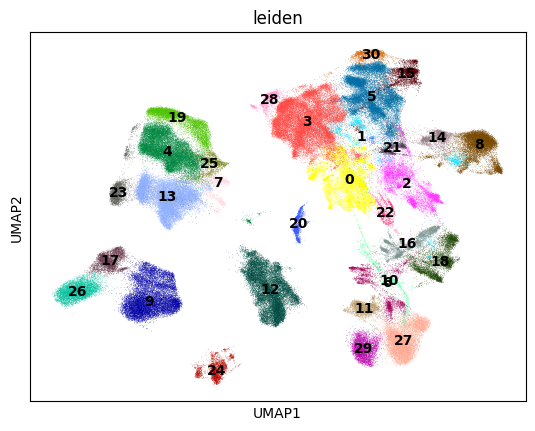

In [9]:
sc.pl.umap(adata, color=["leiden"], legend_loc="on data")

## GPU best practices

The pipeline above runs in seconds on a small dataset. Once you scale up, the habits below are what separate a fast workflow from one that thrashes the GPU.

### Minimize host↔device transfers

Every `anndata_to_GPU` / `anndata_to_CPU` is a PCIe transfer.
A 50 GB sparse matrix takes a few seconds to move and easily dominates fast preprocessing steps.

Move once, do all GPU work in a contiguous block, and move back once.
Avoid patterns like calling a CPU-only function in the middle of a pipeline that forces an implicit move — if you must mix, batch the CPU work.

(introduction-rapids-singlecell-key-takeaway-3)=
### Free intermediates explicitly

Python's garbage collector won't release CuPy memory back to the pool as eagerly as you'd want.
After a memory-heavy step (`rsc.pp.scale` on dense data, `rsc.pp.regress_out`, PCA on a large matrix), drop references to layers you don't need and ask CuPy to release the freed pool blocks back to the driver.

In [10]:
import gc

# Drop references to large intermediates first.
if "counts" in adata.layers:
    del adata.layers["counts"]
gc.collect()

# Then return any unused pool blocks to the driver.
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

### Monitor VRAM usage

It's hard to right-size your pool or diagnose an OOM without seeing what's on the device.
There are three useful views:

In [11]:
# CuPy: what your process has allocated through the active pool.
pool = cp.get_default_memory_pool()
print(f"CuPy pool used: {pool.used_bytes() / 1e9:.2f} GB")
print(f"CuPy pool total: {pool.total_bytes() / 1e9:.2f} GB")

# CUDA: what the device reports as free vs total (across all processes).
free, total = cp.cuda.runtime.memGetInfo()
print(f"Device free: {free / 1e9:.2f} GB / {total / 1e9:.2f} GB")

CuPy pool used: 0.00 GB
CuPy pool total: 0.00 GB
Device free: 93.73 GB / 101.97 GB


From a separate terminal, `nvidia-smi --query-gpu=memory.used,memory.free,utilization.gpu --format=csv -l 1` gives you a per-second feed across processes — indispensable when debugging a pipeline that suddenly OOMs three steps in.

### Watch the dtype

AnnData objects coming from `.h5ad` are commonly `float64`.
On the GPU, `float64` doubles your memory footprint and runs noticeably slower on consumer cards (where FP64 throughput is limited compared to data-center cards).

Cast to `float32` before moving to GPU unless you have a specific numerical reason not to:

```python
adata.X = adata.X.astype("float32")
rsc.get.anndata_to_GPU(adata)
```

RSC computes most reductions internally in `float64` to preserve numerical stability for things like variance and PCA, even when the input is `float32`, so you get the memory savings without the worst-case precision loss.

### Plan for non-determinism

GPU reductions are non-deterministic by default because the order of floating-point summation depends on thread scheduling.
Differences are tiny per element but can flip an HVG ranking near the cutoff or move a cell across a cluster boundary.
If exact reproducibility matters, set `cp.random.seed(...)` and constrain to a single CUDA stream, but accept that bit-identical results across hardware are not realistic.

### Match the NVIDIA driver to the CUDA runtime

RSC wheels pin a specific CUDA runtime version.
Your NVIDIA driver must be at least as new as that runtime; an older driver will fail to load CuPy with a misleading error.
Update the driver, not the toolkit — the wheel ships its own toolkit.

### Know what is not ported

Tools that depend heavily on R packages (SoupX, scDblFinder, scran) and tools that aren't bottlenecks (most plotting) live on CPU.
The expected pattern is to do the bottleneck steps on GPU and bounce back to CPU for the rest.

### Watch for MIG on shared clusters

If you're on a shared cluster, check whether MIG (Multi-Instance GPU) is enabled.
MIG slices a single A100/H100 into smaller, isolated GPUs, which is great for fairness but means you may have less VRAM than `nvidia-smi` on the host suggests.

(introduction-rapids-singlecell-key-takeaway-4)=
## Out-of-core analysis with dask-cuda

When the dataset doesn't fit on a single GPU even with managed memory, RSC integrates with [dask-cuda](https://docs.rapids.ai/api/dask-cuda/stable/) to stream chunks of the matrix through one or more GPUs {cite}`rsc:Rocklin2015`.
AnnData's lazy reader (`read_elem_lazy` in anndata ≥0.12, `read_elem_as_dask` before that) loads `.X` as a Dask array directly from a Zarr or HDF5 store without ever materializing it in host RAM.

The recipe is short but each piece matters.

In [12]:
from dask.distributed import Client
from dask_cuda import LocalCUDACluster

cluster = LocalCUDACluster(
    CUDA_VISIBLE_DEVICES="0",
    threads_per_worker=8,
    protocol="ucx",  # zero-copy GPU↔GPU comms over NVLink/InfiniBand if available
    rmm_pool_size="20GB",
    rmm_maximum_pool_size="40GB",
    rmm_allocator_external_lib_list="cupy",
)
client = Client(cluster)

2026-05-06 11:21:24 | [INFO] To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-06 11:21:24 | [INFO] State start
2026-05-06 11:21:24 | [INFO] Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-91l8od54', purging
2026-05-06 11:21:24 | [INFO] Found stale lock file and directory '/tmp/dask-scratch-space/worker-dmwfgw5g', purging
2026-05-06 11:21:24 | [WARNING] A CUDA context for device 0 (GPU-740d12cd-9ded-6e44-a5b5-5cd90037aebe) already exists on process ID 537888. This is often the result of a CUDA-enabled library calling a CUDA runtime function before Dask-CUDA can spawn worker processes. Please make sure any such function calls don't happen at import time or in the global scope of a program.
2026-05-06 11:21:24 | [INFO]   Scheduler at:     ucx://127.0.0.1:53865
2026-05-06 11:21:24 | [INFO]   dashboard at:  http://127.0.0.1:8787/status
2026-05-06 11:21:24 | [INFO] Registering Worker plug

[1778059284.202777] [2cab62a-lcedt:537888:0]          parser.c:2359 UCX  WARN  unused environment variable: UCX_MEMTYPE_CACHE (maybe: UCX_MEMTYPE_CACHE?)
[1778059284.202777] [2cab62a-lcedt:537888:0]          parser.c:2359 UCX  WARN  (set UCX_WARN_UNUSED_ENV_VARS=n to suppress this warning)


2026-05-06 11:21:24 | [INFO]         Start Nanny at: 'ucx://127.0.0.1:47175'
2026-05-06 11:21:25 | [INFO] Register worker addr: ucx://127.0.0.1:52107 name: 0
2026-05-06 11:21:25 | [INFO] Starting worker compute stream, ucx://127.0.0.1:52107
2026-05-06 11:21:25 | [INFO] Starting established connection to ucx://127.0.0.1:53865
2026-05-06 11:21:25 | [INFO] Receive client connection: Client-f48fc233-492c-11f1-b520-bcfce74fad1a
2026-05-06 11:21:25 | [INFO] Starting established connection to ucx://127.0.0.1:53865


In [13]:
from pathlib import Path

import zarr
from anndata.experimental import read_elem_lazy

# The lazy reader operates on a zarr store, so convert the cached h5ad once.
# In a real workflow you'd already have a zarr atlas on disk or in object storage.
zarr_path = Path(path).with_suffix(".zarr")
if not zarr_path.exists():
    ad.read_h5ad(path).write_zarr(zarr_path)

store = zarr.open(zarr_path)
X_lazy = read_elem_lazy(store["X"], chunks=(20_000, store["X"].attrs["shape"][1]))

adata = ad.AnnData(
    X=X_lazy,
    obs=ad.io.read_elem(store["obs"]),
    var=ad.io.read_elem(store["var"]),
)
rsc.get.anndata_to_GPU(adata)

Two practical points trip up most first-time users of the Dask path:

**Most operations are lazy, but some are not.**
Filtering and `log1p` stay lazy and just queue up work.
`normalize_total` is also lazy *only if you pass `target_sum=` explicitly*; with the default `target_sum=None` it has to compute the per-cell sums to find the median library size, which triggers a synchronization.
`calculate_qc_metrics`, `highly_variable_genes`, `scale`, and `pca` need a full reduction over the matrix and trigger a synchronization — think of those as the natural breakpoints in a Dask pipeline.

**Filter with boolean masks, not `sc.pp.filter_cells`.**
Built-in filtering helpers materialize counts to decide which cells to keep, which defeats lazy execution.
Compute the masks once from QC metrics and apply them directly with `.copy()` to keep things in CSR rather than a view:

```python
adata = adata[adata.obs["n_genes_by_counts"].between(200, 10_000)].copy()
```

**Chunk size is a knob you have to tune.**
Too-small chunks drown the scheduler in tasks; too-large ones blow VRAM on synchronization.
20–50k cells per chunk is a reasonable starting point for a 24–80 GB GPU; profile with the Dask dashboard if a step is slower than expected.

## Beyond preprocessing: decoupler, squidpy, and pertpy on the GPU

RSC also wraps GPU implementations of selected routines from three other scverse packages, each under its own namespace:

- `rsc.dcg.*` — [decoupler](https://decoupler-py.readthedocs.io/) functional analysis (`ulm`, `mlm`, `aucell`, `waggr`, `zscore`). On a million-cell atlas, transcription factor activity inference goes from hours on CPU to minutes on a single GPU. The CPU and GPU APIs are identical aside from the namespace; see the [pathway and gene-set analysis chapter](../conditions/gsea_pathway.ipynb).
- `rsc.gr.*` — [squidpy](https://squidpy.readthedocs.io/) spatial analysis (`spatial_autocorr`, `co_occurrence`, `ligrec`). Moran's/Geary's spatial autocorrelation and the ligand–receptor permutation test are the routines that benefit most from the GPU; see the [spatial neighborhood chapter](../spatial/neighborhood.ipynb) for what these do conceptually. The neighborhood graph itself is still built with `sq.gr.spatial_neighbors` on CPU.
- `rsc.ptg.*` — [pertpy](https://pertpy.readthedocs.io/) perturbation distances via the `Distance` class. Only `edistance` is ported today, with more metrics coming soon. The GPU implementation recomputes distances on the fly rather than materializing an n×n cell-distance matrix, so bootstrap variance estimation becomes practical on screens with hundreds of perturbations; see the [perturbation modeling chapter](../conditions/perturbation_modeling.ipynb).

```python
import decoupler as dc
net = dc.op.collectri(organism="human", license="academic")
rsc.dcg.ulm(adata, net=net, raw=False, bsize=10_000)

import squidpy as sq
sq.gr.spatial_neighbors(adata, coord_type="generic")  # still CPU
rsc.gr.spatial_autocorr(adata, mode="moran")

distance = rsc.ptg.Distance(metric="edistance", obsm_key="X_pca")
df = distance.pairwise(adata, groupby="perturbation")
```

Not the entire upstream API is ported — RSC focuses on the routines that are both heavy enough to be worth a GPU port and embarrassingly parallel enough to stay numerically faithful. Check the RSC API reference for the current coverage.

```{seealso}
:class: dropdown
- [rapids-singlecell documentation](https://rapids-singlecell.readthedocs.io/) — API reference and tutorials, including 1M-cell and out-of-core demos.
- [RAPIDS Memory Manager](https://docs.rapids.ai/api/rmm/stable/) — deeper background on pool, managed, and arena allocators.
- [dask-cuda](https://docs.rapids.ai/api/dask-cuda/stable/) — multi-GPU and out-of-core configuration.
- [cuML user guide](https://docs.rapids.ai/api/cuml/stable/) — the GPU ML library that backs PCA, UMAP, t-SNE, and the logistic regression marker test.
- [NVIDIA Single Cell Analysis blog post](https://developer.nvidia.com/blog/gpu-accelerated-single-cell-rna-analysis-with-rapids-singlecell/) — reference benchmarks against CPU scanpy.
```

## Quiz

In [14]:
%run ../src/lib.py
multiple_choice_question(
    "q1",
    "You have an 80 GB AnnData object and a 40 GB GPU. Which RMM configuration is appropriate?",
    [
        "pool_allocator=True, managed_memory=False",
        "pool_allocator=False, managed_memory=True",
        "pool_allocator=True, managed_memory=True",
        "Don't reinitialize RMM; let the default allocator handle it",
    ],
    "pool_allocator=False, managed_memory=True",
    {
        "pool_allocator=True, managed_memory=False": "A pool allocator caps you at VRAM size. The dataset doesn't fit.",
        "pool_allocator=True, managed_memory=True": "Mixing the two strategies fragments memory and erodes the speedup.",
        "Don't reinitialize RMM; let the default allocator handle it": "The default plain-cudaMalloc allocator works but pays an allocation cost on every temporary array.",
    },
)
multiple_choice_question(
    "q2",
    "Which of the following steps in a Dask-backed RSC pipeline triggers a synchronization (i.e., is not lazy)?",
    [
        "rsc.pp.normalize_total",
        "rsc.pp.log1p",
        "rsc.pp.highly_variable_genes",
        "Boolean indexing into adata",
    ],
    "rsc.pp.highly_variable_genes",
    {
        "rsc.pp.normalize_total": "normalize_total stays lazy.",
        "rsc.pp.log1p": "log1p stays lazy.",
        "Boolean indexing into adata": "Boolean indexing is lazy as long as you avoid sc.pp.filter_cells / .filter_genes.",
    },
)
flip_card(
    "q3",
    "Why should you cast .X to float32 before moving to the GPU?",
    "It halves the VRAM footprint and runs faster on consumer GPUs where FP64 throughput is limited; RSC still uses float64 internally for sensitive reductions.",
)

## References

```{bibliography}
:filter: docname in docnames
```

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Lukas Heumos

### Reviewers

* Severin Dicks